In [2]:
import sys
from pathlib import Path

import pandas as pd, numpy as np, arviz as az, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Make paths robust no matter where the notebook is run from
ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.config import DATA_PROCESSED_DIR, POSTERIORS_DIR

trace_path = Path(POSTERIORS_DIR) / "hbrm_trace.nc"
if not trace_path.exists():
    raise FileNotFoundError(
        f"Missing trace file: {trace_path}. "
        "Run `notebooks/03_hbrm.ipynb` first to generate it (outputs/posteriors/hbrm_trace.nc)."
    )

trace   = az.from_netcdf(trace_path)
df_test = pd.read_csv(Path(DATA_PROCESSED_DIR) / "markets_test.csv")

# Default: categories from test (as originally specified)
categories = sorted(df_test["category_str"].unique().tolist())

# If trace has a different n_cats (e.g., train has categories not present in test), align to training order
n_cats_trace = int(trace.posterior["alpha"].shape[-1])
if len(categories) != n_cats_trace:
    df_train = pd.read_csv(Path(DATA_PROCESSED_DIR) / "markets_train.csv")
    categories = sorted(df_train["category_str"].unique().tolist())

n_cats = len(categories)
assert n_cats == n_cats_trace, f"Category count mismatch: categories={n_cats} vs trace={n_cats_trace}"

In [3]:
alpha_samples = trace.posterior["alpha"].values.reshape(-1, n_cats)
beta_samples  = trace.posterior["beta"].values.reshape(-1, n_cats)

cat_stats = []
for i, cat in enumerate(categories):
    a_samps = alpha_samples[:, i]
    b_samps = beta_samples[:, i]
    a_hdi   = az.hdi(a_samps, hdi_prob=0.94)
    b_hdi   = az.hdi(b_samps, hdi_prob=0.94)
    n_mkt   = (df_test["category_str"] == cat).sum()
    cat_stats.append({
        "category":       cat,
        "n_markets":      int(n_mkt),
        "alpha_mean":     float(a_samps.mean()),
        "alpha_std":      float(a_samps.std()),
        "alpha_hdi_lo":   float(a_hdi[0]),
        "alpha_hdi_hi":   float(a_hdi[1]),
        "alpha_sig":      (a_hdi[0] > 0) or (a_hdi[1] < 0),  # HDI excludes 0
        "beta_mean":      float(b_samps.mean()),
        "beta_std":       float(b_samps.std()),
        "beta_hdi_lo":    float(b_hdi[0]),
        "beta_hdi_hi":    float(b_hdi[1]),
        "beta_sig":       (b_hdi[0] > 1) or (b_hdi[1] < 1),  # HDI excludes 1
        "prob_overconf":  float((b_samps < 1).mean()),   # P(β < 1) = overconfident
        "prob_underconf": float((b_samps > 1).mean()),   # P(β > 1) = underconfident
    })

cat_df = pd.DataFrame(cat_stats)
print(cat_df[["category","n_markets","alpha_mean","alpha_sig","beta_mean","beta_sig",
              "prob_overconf"]].to_string(index=False))

# Save to outputs/
out_csv = ROOT / "outputs" / "per_category_posterior.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
cat_df.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv}")

          category  n_markets  alpha_mean  alpha_sig  beta_mean  beta_sig  prob_overconf
          business         19   -0.036037      False   1.378485     False       0.224375
             chess          6   -0.339347      False   1.375075     False       0.222375
       coronavirus         24    0.156156      False   1.381787     False       0.224125
            crypto         44   -0.794529       True   1.375991     False       0.227875
   global politics          8   -0.252458      False   1.363888     False       0.227625
              nfts         14    0.078884      False   1.378639     False       0.222000
       pop-culture         22   -0.696480       True   1.381407     False       0.219875
           science          9   -0.314597      False   1.372919     False       0.228250
            sports         29   -0.794206       True   1.366850     False       0.230500
  ukraine & russia          9   -0.421234      False   1.374553     False       0.224250
           unknown   

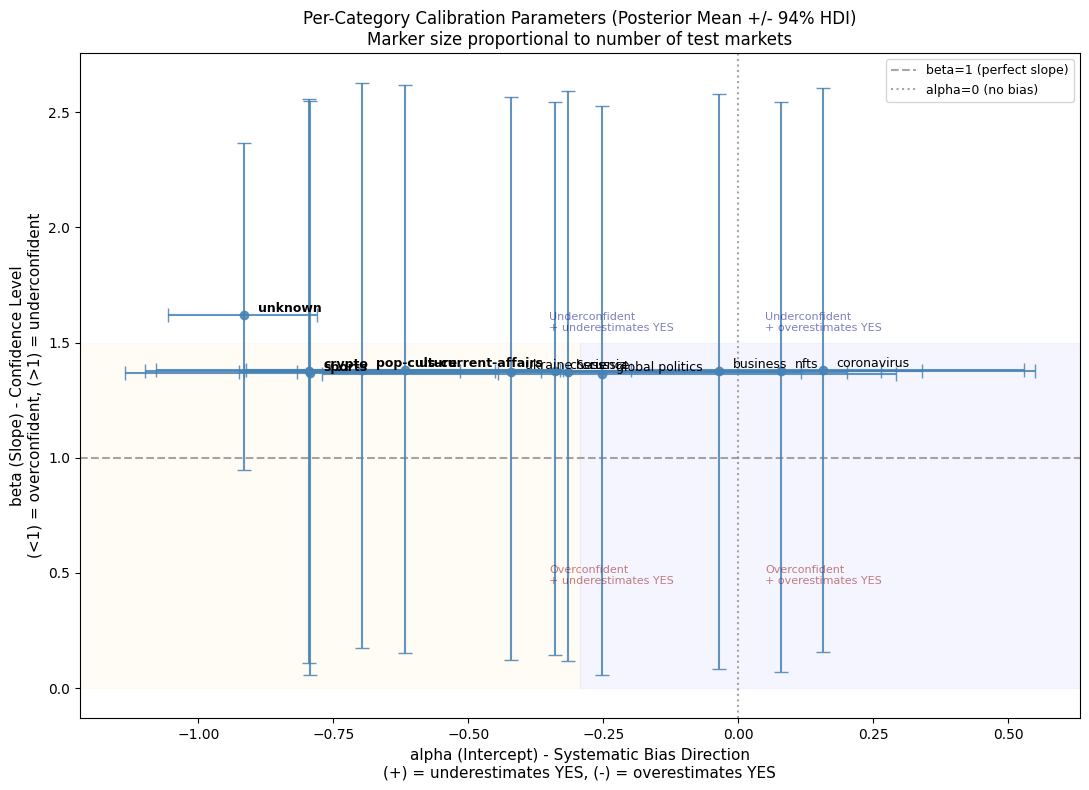

In [4]:
fig, ax = plt.subplots(figsize=(11, 8))

ax.axhspan(0, ax.get_ylim()[1] if ax.get_ylim()[1] > 1.5 else 1.5, xmin=0.5,
           alpha=0.04, color='blue')
ax.axhspan(0, 1.5, xmin=0, xmax=0.5, alpha=0.04, color='orange')

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label="beta=1 (perfect slope)")
ax.axvline(0.0, color='gray', linestyle=':',  linewidth=1.5, alpha=0.7, label="alpha=0 (no bias)")

colors_scatter = plt.cm.RdBu(cat_df["prob_overconf"])

for _, row in cat_df.iterrows():
    ax.errorbar(
        row["alpha_mean"], row["beta_mean"],
        xerr=[[row["alpha_mean"] - row["alpha_hdi_lo"]],
              [row["alpha_hdi_hi"] - row["alpha_mean"]]],
        yerr=[[row["beta_mean"] - row["beta_hdi_lo"]],
              [row["beta_hdi_hi"] - row["beta_mean"]]],
        fmt='o', capsize=5, markersize=max(6, np.sqrt(row["n_markets"])*0.3),
        color='crimson' if row["prob_overconf"] > 0.7 else 'steelblue',
        alpha=0.85, linewidth=1.5
    )
    ax.annotate(row["category"],
                (row["alpha_mean"], row["beta_mean"]),
                textcoords="offset points", xytext=(10, 2),
                fontsize=9, fontweight='bold' if row["alpha_sig"] or row["beta_sig"] else 'normal')

ax.text( 0.05, 1.55, "Underconfident\n+ overestimates YES", fontsize=8, color='navy',  alpha=0.5, ha='left')
ax.text(-0.35, 1.55, "Underconfident\n+ underestimates YES", fontsize=8, color='navy', alpha=0.5, ha='left')
ax.text( 0.05, 0.45, "Overconfident\n+ overestimates YES",  fontsize=8, color='darkred',alpha=0.5, ha='left')
ax.text(-0.35, 0.45, "Overconfident\n+ underestimates YES", fontsize=8, color='darkred',alpha=0.5, ha='left')

ax.set_xlabel("alpha (Intercept) - Systematic Bias Direction\n(+) = underestimates YES, (-) = overestimates YES", fontsize=11)
ax.set_ylabel("beta (Slope) - Confidence Level\n(<1) = overconfident, (>1) = underconfident", fontsize=11)
ax.set_title("Per-Category Calibration Parameters (Posterior Mean +/- 94% HDI)\nMarker size proportional to number of test markets", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("outputs/figures/17_category_alpha_beta_scatter.png", dpi=200, bbox_inches='tight')
plt.show()

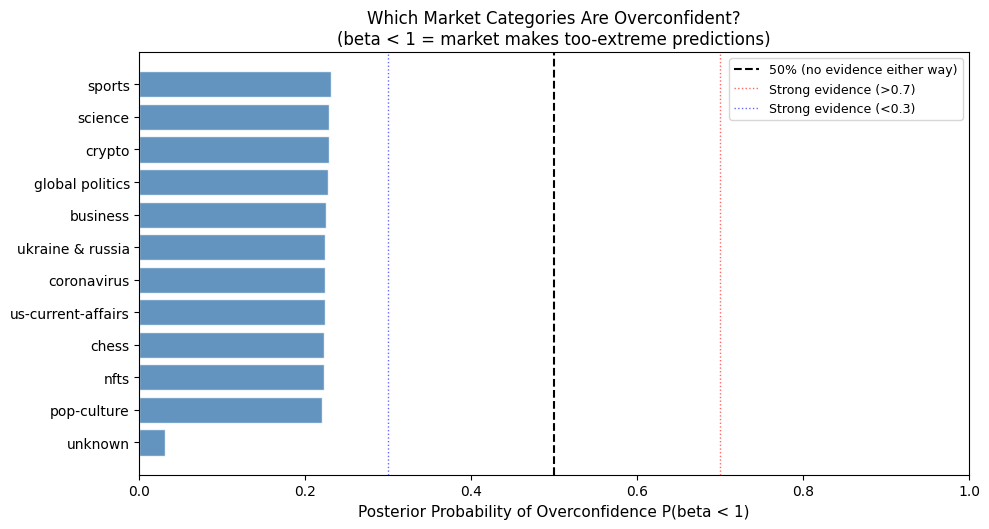

In [5]:
cat_sorted = cat_df.sort_values("prob_overconf", ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, n_cats * 0.45)))
colors_bar = ['crimson' if p > 0.7 else ('steelblue' if p < 0.3 else 'gray')
              for p in cat_sorted["prob_overconf"]]
ax.barh(cat_sorted["category"], cat_sorted["prob_overconf"],
        color=colors_bar, alpha=0.85, edgecolor='white')
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label="50% (no evidence either way)")
ax.axvline(0.7, color='red',   linestyle=':',  lw=1,   alpha=0.6, label="Strong evidence (>0.7)")
ax.axvline(0.3, color='blue',  linestyle=':',  lw=1,   alpha=0.6, label="Strong evidence (<0.3)")
ax.set_xlabel("Posterior Probability of Overconfidence P(beta < 1)", fontsize=11)
ax.set_title("Which Market Categories Are Overconfident?\n(beta < 1 = market makes too-extreme predictions)", fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig("outputs/figures/18_overconfidence_probability.png", dpi=200, bbox_inches='tight')
plt.show()

In [6]:
print("=" * 70)
print("POSTERIOR INTERPRETATION SUMMARY")
print("=" * 70)
for _, row in cat_df.sort_values("prob_overconf", ascending=False).iterrows():
    bias = "underestimates YES" if row["alpha_mean"] > 0 else "overestimates YES"
    conf = "overconfident" if row["prob_overconf"] > 0.6 else "underconfident" if row["prob_overconf"] < 0.4 else "well-calibrated slope"
    sig  = "(statistically significant)" if row["alpha_sig"] or row["beta_sig"] else "(not significant)"
    print(f"\n{row['category'].upper()} (n={row['n_markets']}):")
    print(f"  alpha={row['alpha_mean']:+.3f}: Market {bias}")
    print(f"  beta={row['beta_mean']:.3f}: Market is {conf} {sig}")
    print(f"  P(overconfident) = {row['prob_overconf']:.3f}")

POSTERIOR INTERPRETATION SUMMARY

SPORTS (n=29):
  alpha=-0.794: Market overestimates YES
  beta=1.367: Market is underconfident (statistically significant)
  P(overconfident) = 0.231

SCIENCE (n=9):
  alpha=-0.315: Market overestimates YES
  beta=1.373: Market is underconfident (not significant)
  P(overconfident) = 0.228

CRYPTO (n=44):
  alpha=-0.795: Market overestimates YES
  beta=1.376: Market is underconfident (statistically significant)
  P(overconfident) = 0.228

GLOBAL POLITICS (n=8):
  alpha=-0.252: Market overestimates YES
  beta=1.364: Market is underconfident (not significant)
  P(overconfident) = 0.228

BUSINESS (n=19):
  alpha=-0.036: Market overestimates YES
  beta=1.378: Market is underconfident (not significant)
  P(overconfident) = 0.224

UKRAINE & RUSSIA (n=9):
  alpha=-0.421: Market overestimates YES
  beta=1.375: Market is underconfident (not significant)
  P(overconfident) = 0.224

CORONAVIRUS (n=24):
  alpha=+0.156: Market underestimates YES
  beta=1.382: Marke